In [1]:
import sys
sys.path.append('..')

import numpy as np
import hmm
import emission_model
import matplotlib.pyplot as plt
from utils import Student, accept_reject

# Test on synthetic HMM with Student emissions


In [2]:
mu_th    = [0.05,  -0.01]
sigma_th = [0.008,  0.015]
nu_th = [20, 3]

A_th = np.array([[0.9, 0.1],
                  [0.05, 0.95]])



def generate_student_data(A_th, mu_th, sigma_th, nu_th,T=2000, seed=42):
    
    fmax_s= []
    
    for s in range(len(mu_th)):
        fmax_s.append(Student(mu_th[s], mu_th[s], sigma_th[s], nu_th[s]))
    
    rng = np.random.default_rng(seed)
    
    states, obs = [], []
    s = 0
    for _ in range(T):
        states.append(s)
        # Student's t sample
        x = accept_reject(Student, [mu_th[s], sigma_th[s], nu_th[s]], fmax=fmax_s[0], xmin=mu_th[s]-10*sigma_th[s], xmax=mu_th[s]+10*sigma_th[s])
        obs.append(x)
        s = rng.choice(2, p=A_th[s])

    return np.array(obs), np.array(states)

In [3]:
obs, states = generate_student_data(A_th, mu_th, sigma_th, nu_th,T=20000, seed=42)
obs=obs.reshape((1, obs.shape[0]))

(array([  2.,   0.,   1.,   0.,   0.,   1.,   1.,   1.,   2.,   0.,   0.,
          1.,   0.,   0.,   1.,   1.,   1.,   0.,   2.,   0.,   1.,   0.,
          1.,   0.,   1.,   1.,   0.,   2.,   0.,   0.,   1.,   1.,   1.,
          3.,   1.,   1.,   1.,   0.,   3.,   1.,   1.,   1.,   0.,   0.,
          0.,   1.,   3.,   1.,   4.,   2.,   1.,   1.,   1.,   5.,   3.,
          4.,   5.,   2.,   1.,   1.,   7.,   2.,   7.,   4.,   5.,   7.,
          9.,  14.,   6.,   5.,   4.,   6.,   8.,  13.,  11.,   9.,  15.,
         15.,  11.,   8.,  16.,  11.,  12.,  15.,  21.,  14.,  20.,  14.,
         29.,  24.,  29.,  39.,  38.,  29.,  44.,  38.,  51.,  57.,  69.,
         60.,  53.,  80.,  63., 105.,  89.,  97., 111., 150., 150., 139.,
        165., 189., 197., 226., 232., 263., 261., 308., 318., 287., 372.,
        323., 369., 394., 343., 374., 399., 409., 343., 363., 373., 373.,
        335., 320., 263., 258., 237., 239., 231., 202., 175., 173., 163.,
        133., 147., 116., 114., 102., 

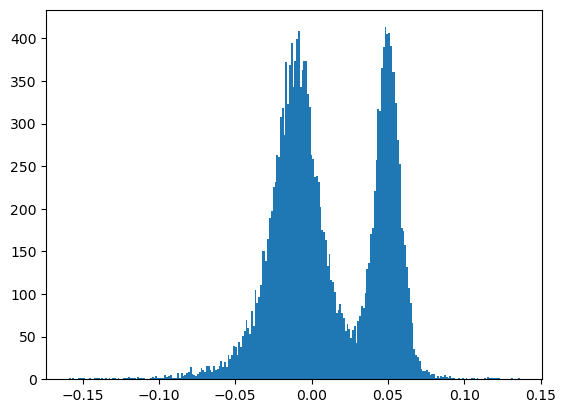

In [4]:
plt.hist(obs[0, :], bins=250)

In [5]:
from tqdm import tqdm
### Student emissions
lkl_t = []
final_lkl = []
HMM_list = []
N_cycles = 10

for i in range(N_cycles):
    
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), 5],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), 15],  # state 1
    ])
    
    emission = emission_model.Student_Emission(2, obs, params)
    HMM = hmm.Hmm(2, emission, pi, A=None, eps=1e-8)
    
    lkl_t.append(HMM.Baum_Welch(obs, N_max=35))
    final_lkl.append(lkl_t[i][-1])
    HMM_list.append(HMM)
    

############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  logL =       1.589131  |  ΔL/L = 100.000000%
Iteration    2  |  logL =       1.924273  |  ΔL/L = 21.089603%
Iteration    3  |  logL =       1.958231  |  ΔL/L = 1.764748%
Iteration    4  |  logL =       2.153494  |  ΔL/L = 9.971407%
Iteration    5  |  logL =       2.368555  |  ΔL/L = 9.986617%
Iteration    6  |  logL =       2.503709  |  ΔL/L = 5.706171%
Iteration    7  |  logL =       2.530980  |  ΔL/L = 1.089193%
Iteration    8  |  logL =       2.531560  |  ΔL/L = 0.022935%
Iteration    9  |  logL =       2.531577  |  ΔL/L = 0.000680%
Iteration   10  |  logL =       2.531578  |  ΔL/L = 0.000037%
Iteration   11  |  logL =       2.531578  |  ΔL/L = 0.000005%
Iteration   12  |  logL =       2.531578  |  ΔL/L = 0.000001%
Learning Finish

In [8]:
# choose the HMM with the lowest -logL
HMM = HMM_list[np.argmax(np.array(final_lkl))]

HMM.emission.params = HMM.emission.params[np.argsort(HMM.emission.params[:, 0]), :]

th_sort = np.argsort(np.array(mu_th))
mu_th = np.array(mu_th)[th_sort]
sigma_th = np.array(sigma_th)[th_sort]
nu_th = np.array(nu_th)[th_sort]

print(r'Synthetic Student generating processes$ (\mu, \sigma, \nu)$: ')
print(' ')
print([(float(mu_th[i]), float(sigma_th[i]), float(nu_th[i])) for i in range(len(mu_th))])
print(' ')
print(r'Learned Student generating processes: HMM.emission.params')
print(' ')
print([(float(np.round(HMM.emission.params[i, 0], 4)), (float(np.round(HMM.emission.params[i, 1], 4))), (float(np.round(HMM.emission.params[i, 2], 4)))) for i in range(HMM.emission.params.shape[0])])



Synthetic Student generating processes$ (\mu, \sigma, \nu)$: 
 
[(-0.01, 0.015, 3.0), (0.05, 0.008, 20.0)]
 
Learned Student generating processes: HMM.emission.params
 
[(-0.01, 0.0154, 3.4935), (0.0499, 0.0078, 12.0315)]


Perfect quantitative agreement between synthetic parameters and learned parameters; the learned $\nu = 12.0315$ is already in the Gaussian regime, agreeing with the synthetic 20.